In [75]:
"""
PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
BỘ DỮ LIỆU MARKETING CAMPAIGN
"""

'\nPHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)\nBỘ DỮ LIỆU MARKETING CAMPAIGN\n'

In [29]:
import numpy as np 
import pandas as pd 
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pip install autoviz

In [32]:
import sys
print(sys.version)
print(sys.executable)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
c:\ProgramData\anaconda3\python.exe


In [33]:
import sys
!{sys.executable} -m pip --version

pip 25.3 from c:\ProgramData\anaconda3\Lib\site-packages\pip (python 3.13)



In [48]:
import pandas as pd

df = pd.read_csv(
    r'C:/Users/MANH QUYNH/Downloads/marketing_campaign.csv',
    sep='\t'
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.head()
df.info()
df.describe()
df.columns

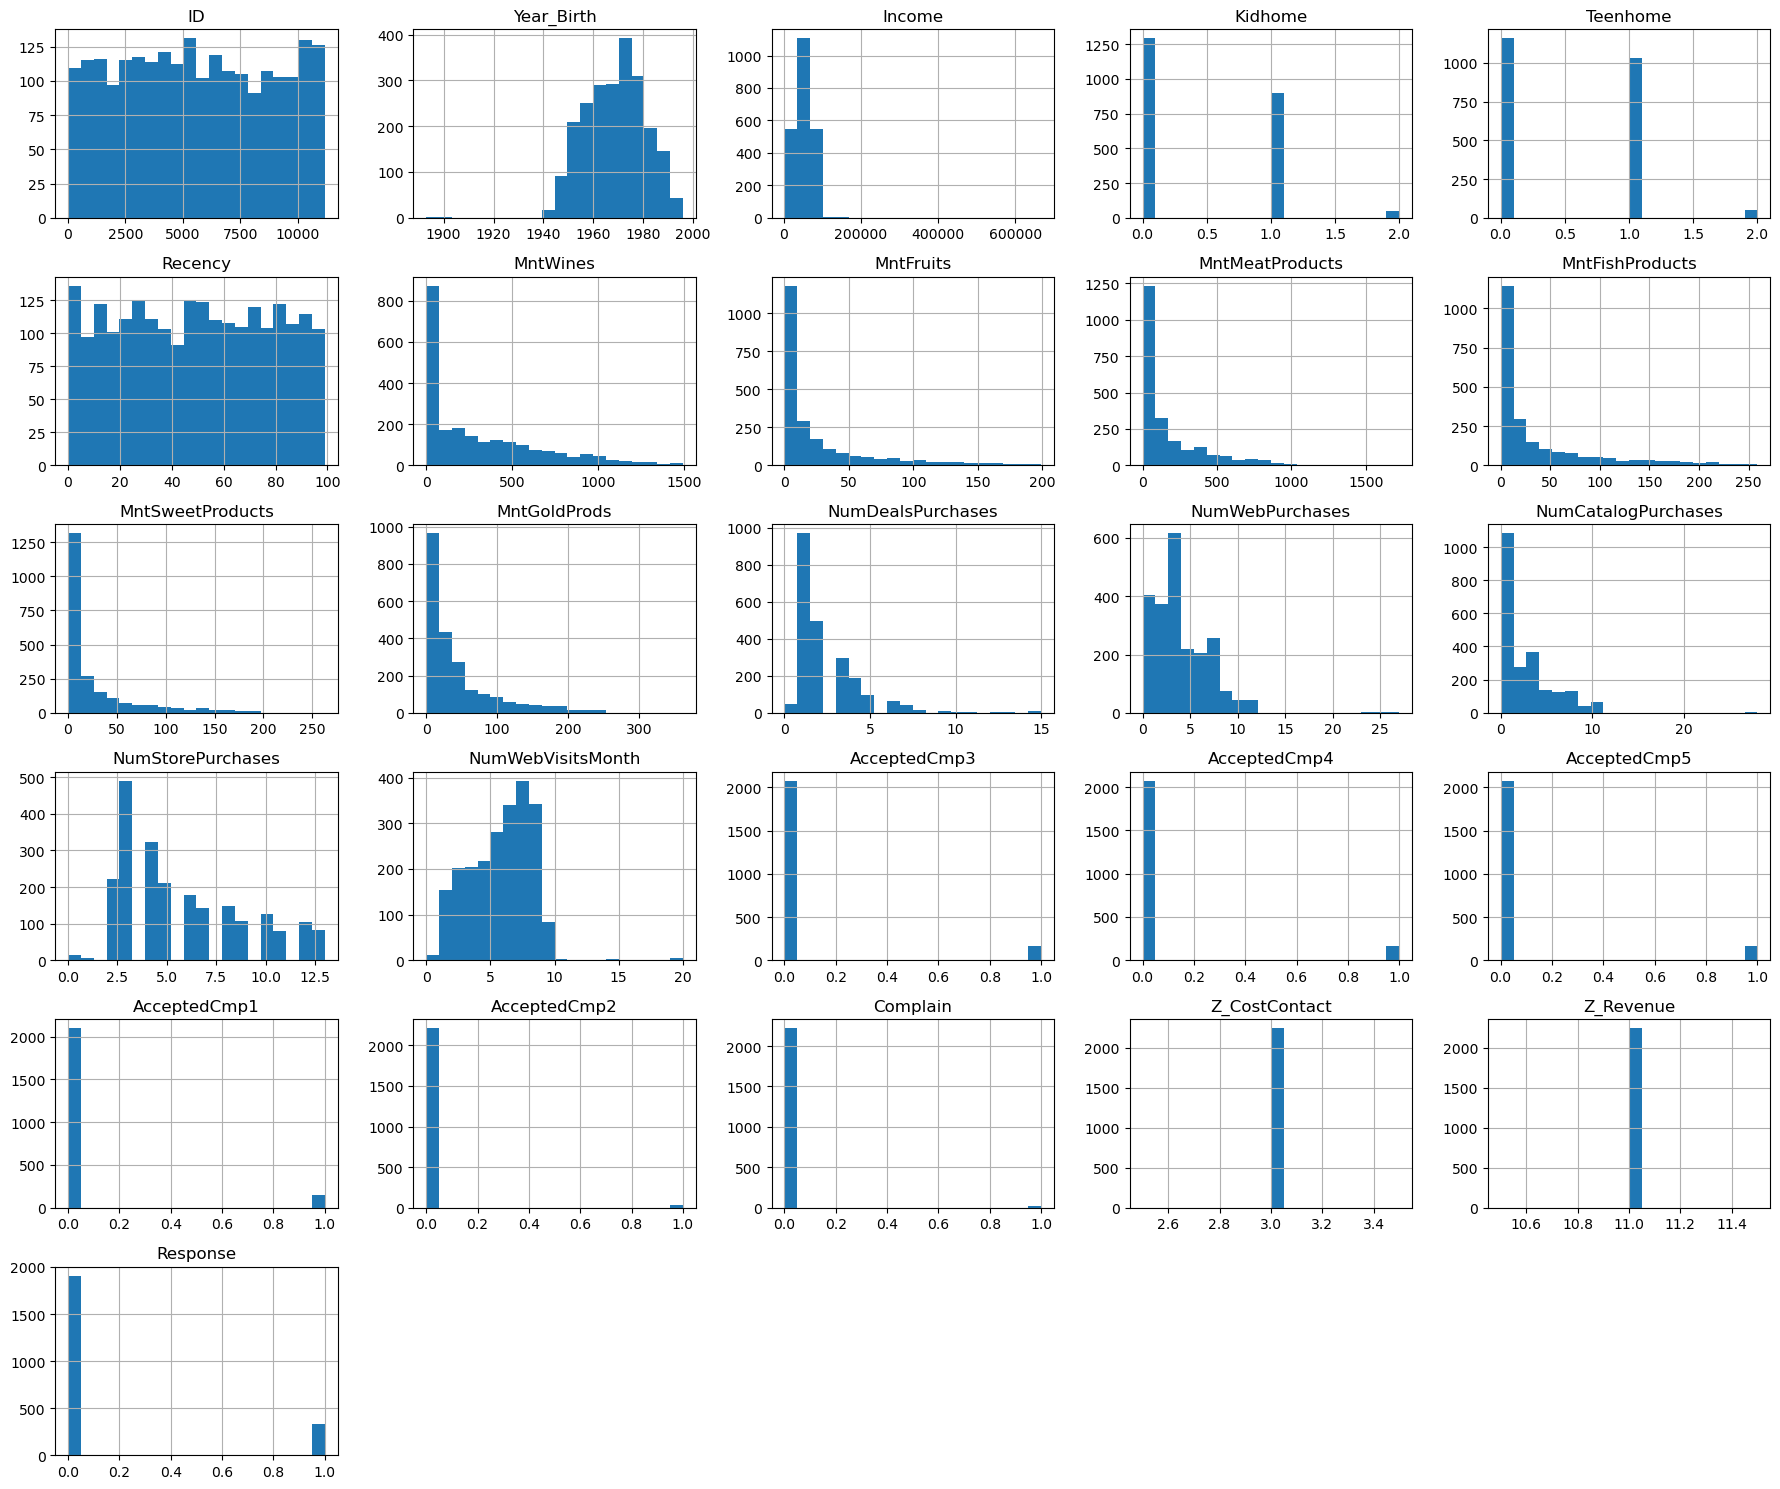

In [ ]:
#Histogram tất cả biến số
import matplotlib.pyplot as plt

df.hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()
plt.show()

In [54]:
#Phân tích độ tuổi khách hàng
df['Age'] = 2025 - df['Year_Birth']

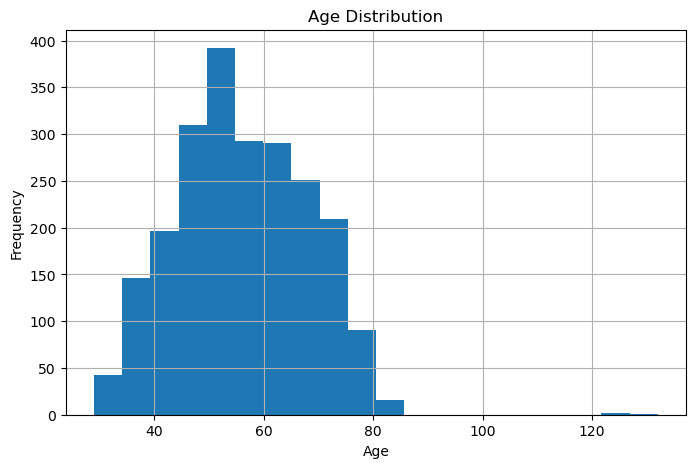

In [55]:
#Biểu đồ
plt.figure(figsize=(8,5))
df['Age'].hist(bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

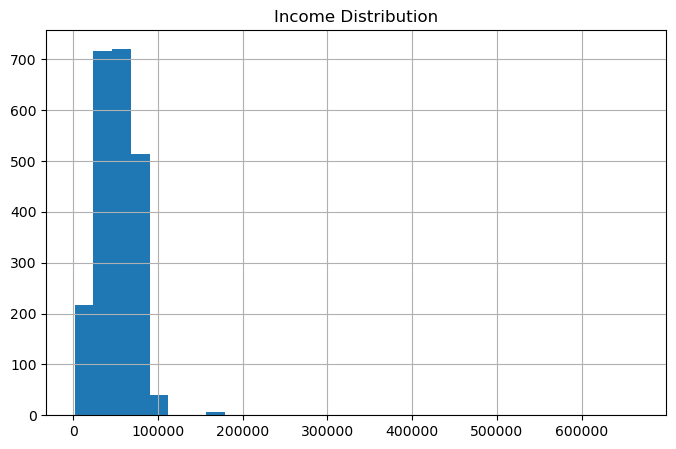

In [56]:
#Phân tích thu nhập (Income)
plt.figure(figsize=(8,5))
df['Income'].hist(bins=30)

plt.title('Income Distribution')
plt.show()

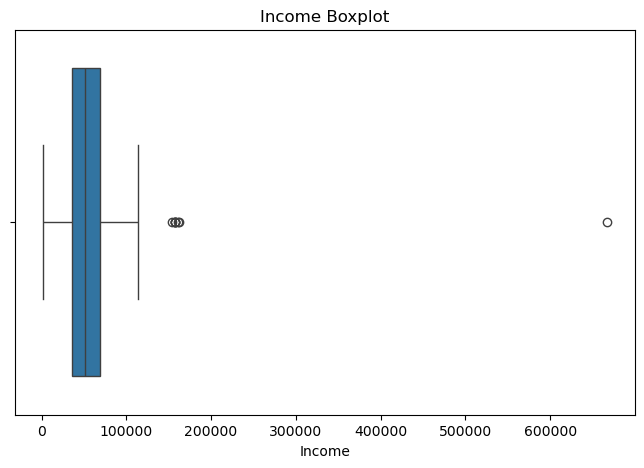

In [57]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Income'])

plt.title('Income Boxplot')
plt.show()

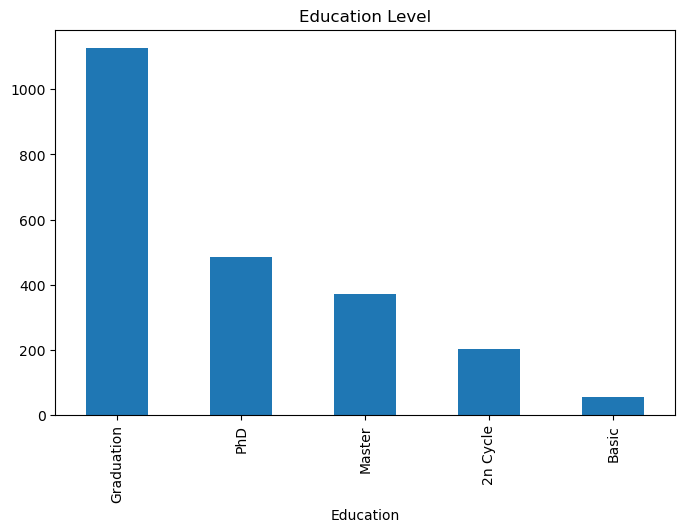

In [58]:
#Phân tích trình độ học vấn
plt.figure(figsize=(8,5))

df['Education'].value_counts().plot(
    kind='bar'
)

plt.title('Education Level')
plt.show()

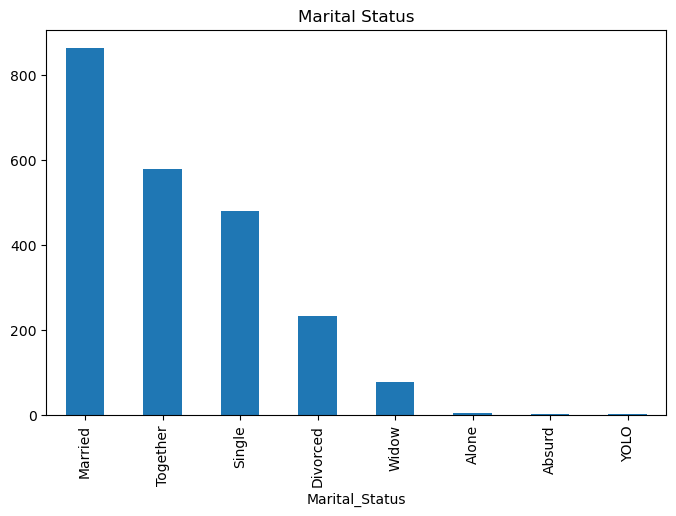

In [59]:
#Phân tích tình trạng hôn nhân
plt.figure(figsize=(8,5))

df['Marital_Status'].value_counts().plot(
    kind='bar'
)

plt.title('Marital Status')
plt.show()

In [61]:
#Tổng chi tiêu của khách hàng
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)
df[['Income','Total_Spending']].head()

,Income,Total_Spending
0,58138.0,1617
1,46344.0,27
2,71613.0,776
3,26646.0,53
4,58293.0,422


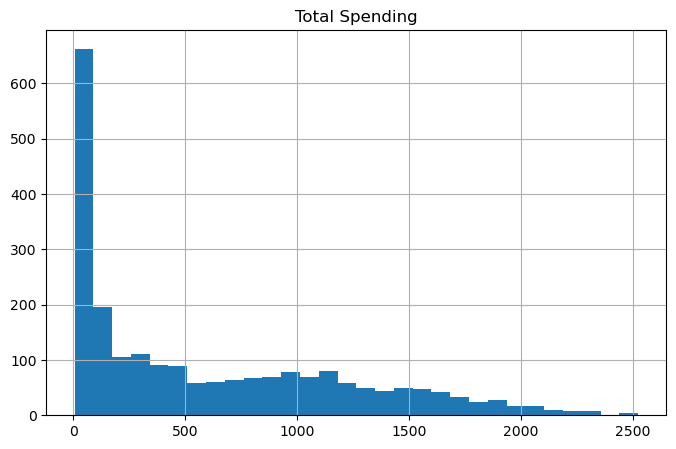

In [62]:
plt.figure(figsize=(8,5))

df['Total_Spending'].hist(
    bins=30
)

plt.title('Total Spending')
plt.show()

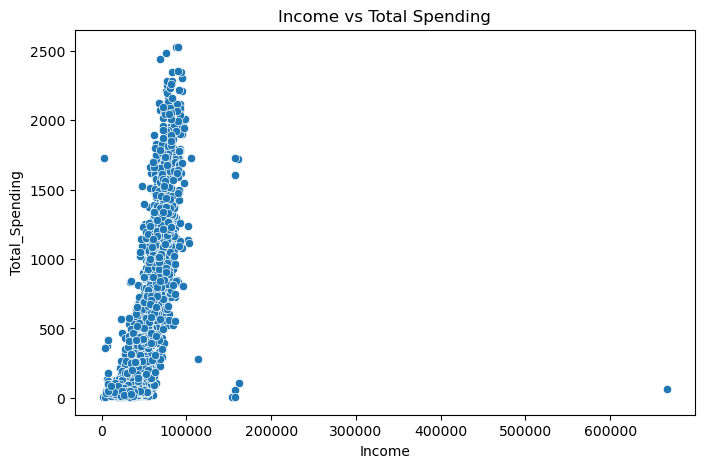

In [63]:
#Quan hệ Thu nhập và Chi tiêu
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending'
)

plt.title('Income vs Total Spending')
plt.show()

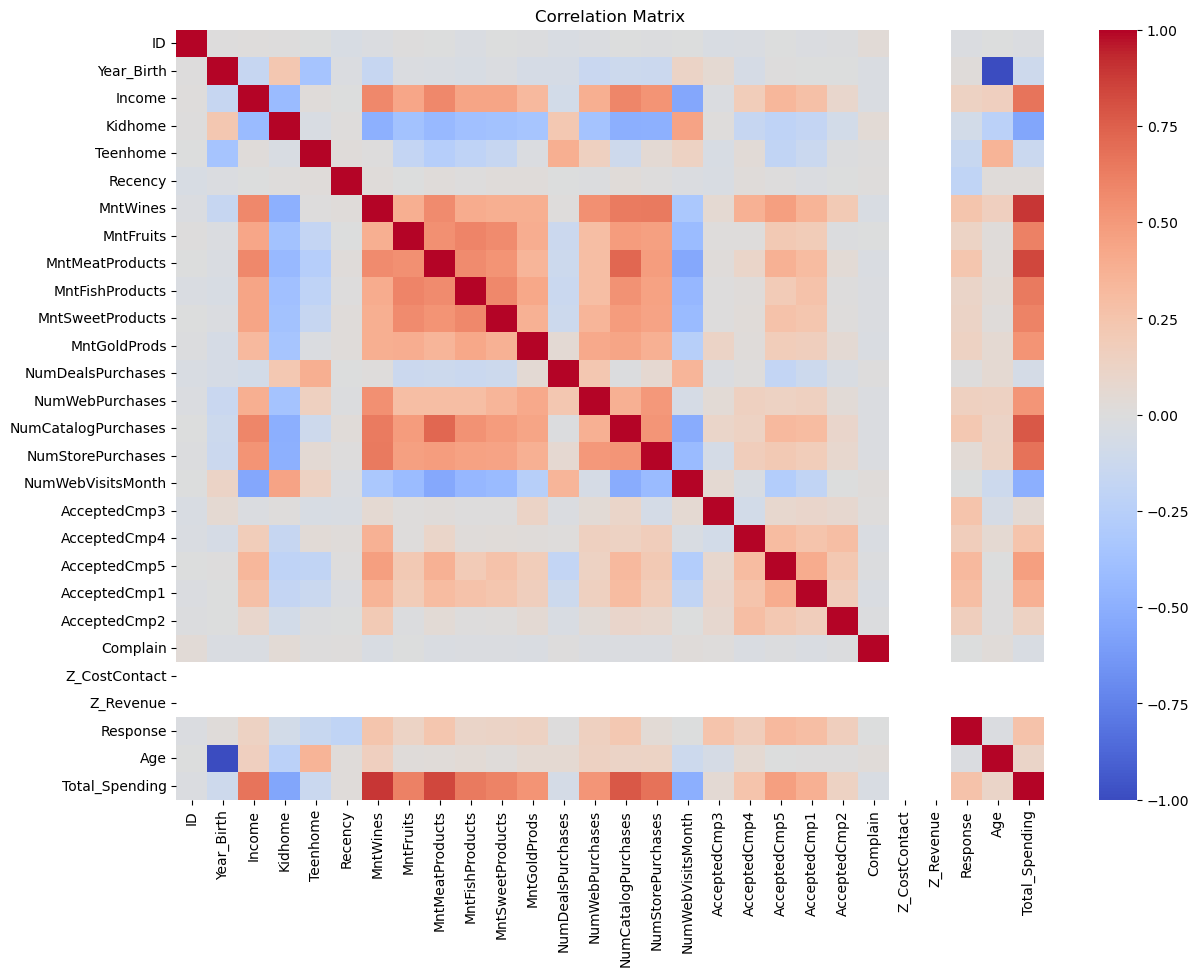

In [64]:
#Ma trận tương quan
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Matrix')
plt.show()

In [65]:
#Phân tích Response (Hiệu quả Marketing)
df['Response'].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

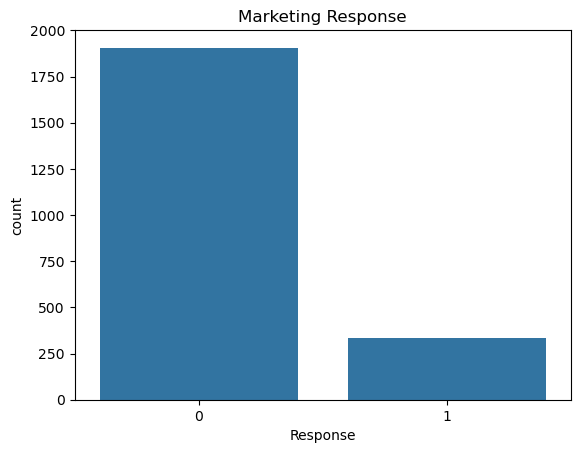

In [66]:
sns.countplot(
    data=df,
    x='Response'
)

plt.title('Marketing Response')
plt.show()

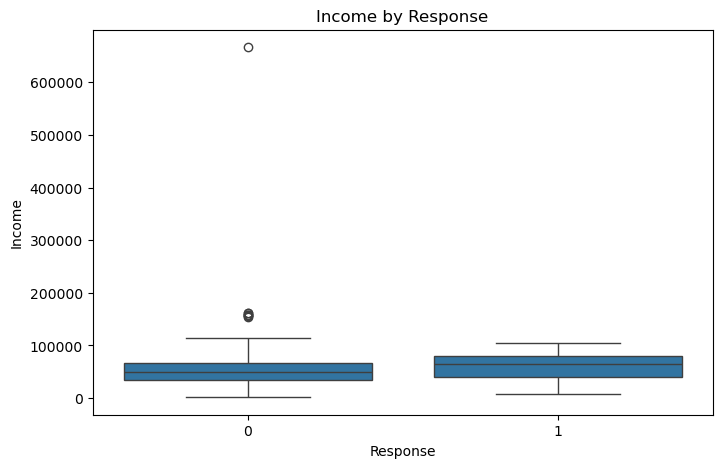

In [67]:
#Thu nhập theo phản hồi chiến dịch
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Response',
    y='Income'
)

plt.title('Income by Response')
plt.show()

In [68]:
#Top biến tương quan với Response
corr_response = numeric_df.corr()['Response']

print(
    corr_response.sort_values(
        ascending=False
    )
)

Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
Total_Spending         0.265298
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
Age                   -0.021325
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Z_CostContact               NaN
Z_Revenue                   NaN
Name: Response, dtype: float64


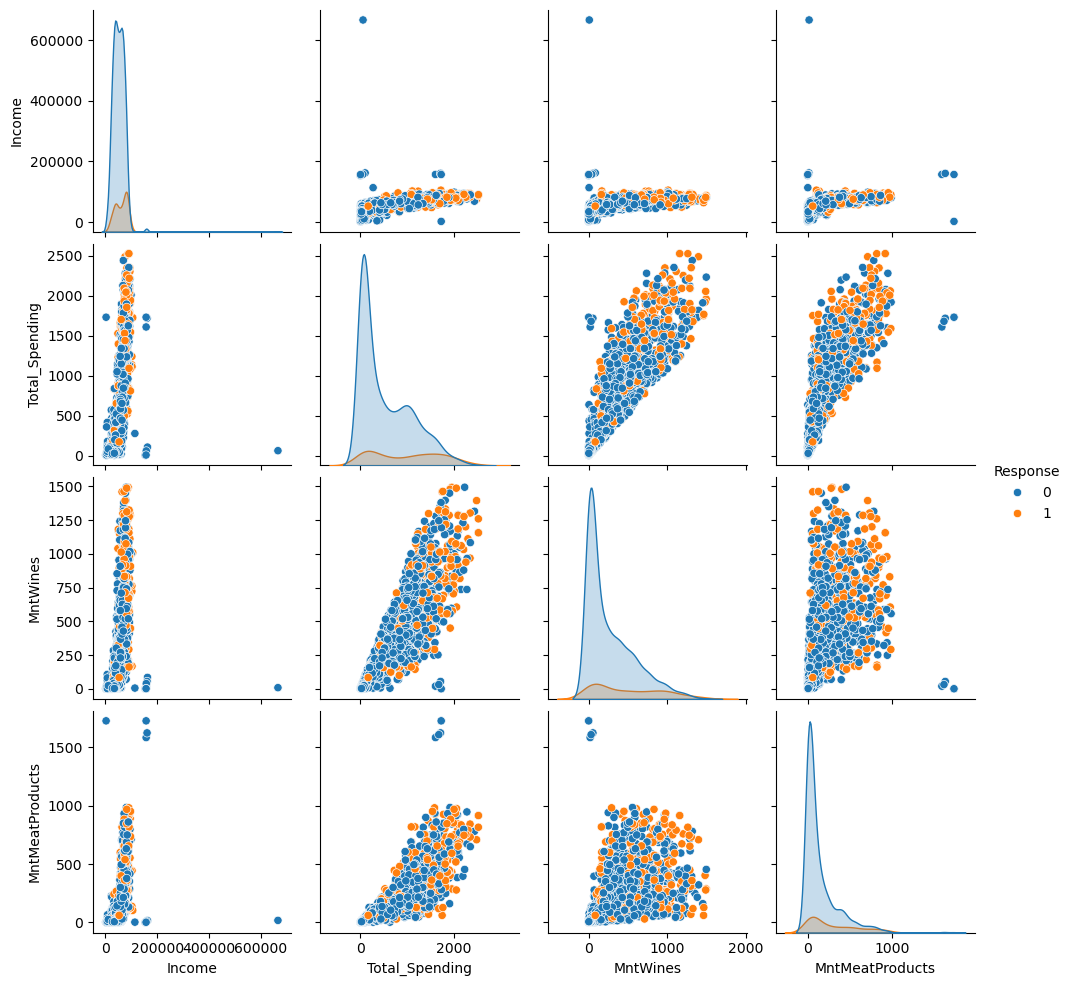

In [69]:
#Pairplot các biến quan trọng
sns.pairplot(
    df[
        [
            'Income',
            'Total_Spending',
            'MntWines',
            'MntMeatProducts',
            'Response'
        ]
    ],
    hue='Response'
)

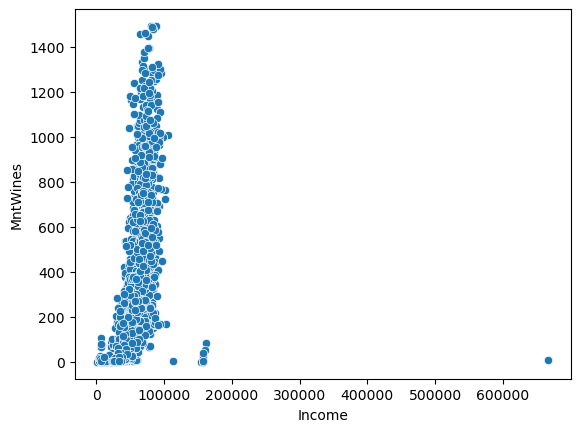

In [70]:
#Quan hệ Income và MntWines
sns.scatterplot(
    data=df,
    x='Income',
    y='MntWines'
)
plt.show()